# Modeling UofT Finances

The purpose of this notebook is to model my expected costs and earnings as a first-year student in UofT. I consider multiple scenarios, across multiple residences (to help in choosing one).

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Base Costs

To start, I'm going to model my base cost estimates. The categories are:
- Fixed Costs
  - Tuition and Fees (two payments: Fall in September, Winter in January)
  - Residence (Also two payments, Sep and Nov)
- Variable Costs
  - Food
  - Transportation (pay-per ride, TTC Student Pass, TTC Adult Pass as proxies)
  - Phone Bill (I have to do more detailed research, but see a $45 Freedom plan for students)
  - Health & Personal Care (toiletries and such)
  - Entertainment (going out with friends and such)
  - Miscellaneous (a buffer)

In [125]:
fixed_costs = ['Tuition & Fees', 'Residence']
variable_costs = ['Books & Supplies', 'Food', 'Transportation', 'Phone Bill', 'Health & Personal Care', 'Entertainment', 'Miscellaneous']
var_base = {'Books & Supplies': 40,'Food': 300, 'Transportation': 130, 'Phone Bill': 45, 'Health & Personal Care': 120, 'Entertainment': 150, 'Miscellaneous': 70}

In [126]:
base_costs = pd.DataFrame(0.0, index=pd.date_range('2026-09-01', periods=8, freq='MS'), columns=fixed_costs+variable_costs)
base_costs.index.name = 'Date'

# Setting the fixed costs
base_costs.loc['2026-09-01', 'Tuition & Fees'] = 3850 # First tuition payment
base_costs.loc['2027-01-01', 'Tuition & Fees'] = 3850 # Second tuition payment
base_costs.loc['2026-09-01', 'Residence'] = 7497 # First residence payment, Woodsworth
base_costs.loc['2027-01-01', 'Residence'] = 5118 # Second residence payment

for cost in variable_costs:
    base_costs[cost] = var_base[cost]

base_costs

,Tuition & Fees,Residence,Books & Supplies,Food,Transportation,Phone Bill,Health & Personal Care,Entertainment,Miscellaneous
Date,,,,,,,,,
2026-09-01,3850.0,7497.0,40,300,130,45,120,150,70
2026-10-01,0.0,0.0,40,300,130,45,120,150,70
2026-11-01,0.0,0.0,40,300,130,45,120,150,70
2026-12-01,0.0,0.0,40,300,130,45,120,150,70
2027-01-01,3850.0,5118.0,40,300,130,45,120,150,70
2027-02-01,0.0,0.0,40,300,130,45,120,150,70
2027-03-01,0.0,0.0,40,300,130,45,120,150,70
2027-04-01,0.0,0.0,40,300,130,45,120,150,70


## Optimistic and Pessimistic Costs

Now I'm going to input my optimistic and pessimistic forecasts for the same categories.

In [127]:
opt_costs = base_costs.copy()
pess_costs = base_costs.copy()

var_opt = {'Books & Supplies': 10,'Food': 200, 'Transportation': 100, 'Phone Bill': 45, 'Health & Personal Care': 80, 'Entertainment': 60, 'Miscellaneous': 40}

var_pess = {'Books & Supplies': 120,'Food': 450, 'Transportation': 165, 'Phone Bill': 45, 'Health & Personal Care': 200, 'Entertainment': 300, 'Miscellaneous': 150}

for cost in variable_costs:
    opt_costs[cost] = var_opt[cost]
    pess_costs[cost] = var_pess[cost]

In [128]:
pess_costs

,Tuition & Fees,Residence,Books & Supplies,Food,Transportation,Phone Bill,Health & Personal Care,Entertainment,Miscellaneous
Date,,,,,,,,,
2026-09-01,3850.0,7497.0,120,450,165,45,200,300,150
2026-10-01,0.0,0.0,120,450,165,45,200,300,150
2026-11-01,0.0,0.0,120,450,165,45,200,300,150
2026-12-01,0.0,0.0,120,450,165,45,200,300,150
2027-01-01,3850.0,5118.0,120,450,165,45,200,300,150
2027-02-01,0.0,0.0,120,450,165,45,200,300,150
2027-03-01,0.0,0.0,120,450,165,45,200,300,150
2027-04-01,0.0,0.0,120,450,165,45,200,300,150


In [129]:
opt_costs

,Tuition & Fees,Residence,Books & Supplies,Food,Transportation,Phone Bill,Health & Personal Care,Entertainment,Miscellaneous
Date,,,,,,,,,
2026-09-01,3850.0,7497.0,10,200,100,45,80,60,40
2026-10-01,0.0,0.0,10,200,100,45,80,60,40
2026-11-01,0.0,0.0,10,200,100,45,80,60,40
2026-12-01,0.0,0.0,10,200,100,45,80,60,40
2027-01-01,3850.0,5118.0,10,200,100,45,80,60,40
2027-02-01,0.0,0.0,10,200,100,45,80,60,40
2027-03-01,0.0,0.0,10,200,100,45,80,60,40
2027-04-01,0.0,0.0,10,200,100,45,80,60,40


## Revenues

Now here, I'm going to repeat the above method, but instead for my revenues by category. I will do optimistic, base, and pessimistic all in one block to save space.

In [130]:
fixed_revenues = ['OSAP Grants', 'OSAP Loans', 'UTAPS', 'Scholarships']
variable_revenues = ['Work']
base_starting_balance = 17.60 * 35 * 16 # Summer work estimate: ontario min wage * 35hrs/week.

base_rev = pd.DataFrame(0.0, index=pd.date_range('2026-09-01', periods=8, freq='MS'), columns=fixed_revenues+variable_revenues)
base_rev.index.name = 'Date'

base_rev['Work'] = 17.60 * 10 * 4  # Ontario min wage * 10hrs/week; base estimate
base_rev.loc['2026-09-01', 'OSAP Grants'] = 13569*0.25 # First OSAP grant
base_rev.loc['2026-09-01', 'OSAP Loans'] = 13569*0.75 # First OSAP loan
base_rev.loc['2027-01-01', 'OSAP Grants'] = 9046*0.25 # Second OSAP grant
base_rev.loc['2027-01-01', 'OSAP Loans'] = 9046*0.75 # Second OSAP loan
base_rev.loc['2026-10-01', 'UTAPS'] = 3000

base_rev


,OSAP Grants,OSAP Loans,UTAPS,Scholarships,Work
Date,,,,,
2026-09-01,3392.25,10176.75,0.0,0.0,704.0
2026-10-01,0.00,0.00,3000.0,0.0,704.0
2026-11-01,0.00,0.00,0.0,0.0,704.0
2026-12-01,0.00,0.00,0.0,0.0,704.0
2027-01-01,2261.50,6784.50,0.0,0.0,704.0
2027-02-01,0.00,0.00,0.0,0.0,704.0
2027-03-01,0.00,0.00,0.0,0.0,704.0
2027-04-01,0.00,0.00,0.0,0.0,704.0


In [131]:
pess_rev = base_rev.copy()
pess_rev['Work'] = 17.60 * 5 * 4
pess_starting_balance = 17.60 * 25 * 12

pess_rev


,OSAP Grants,OSAP Loans,UTAPS,Scholarships,Work
Date,,,,,
2026-09-01,3392.25,10176.75,0.0,0.0,352.0
2026-10-01,0.00,0.00,3000.0,0.0,352.0
2026-11-01,0.00,0.00,0.0,0.0,352.0
2026-12-01,0.00,0.00,0.0,0.0,352.0
2027-01-01,2261.50,6784.50,0.0,0.0,352.0
2027-02-01,0.00,0.00,0.0,0.0,352.0
2027-03-01,0.00,0.00,0.0,0.0,352.0
2027-04-01,0.00,0.00,0.0,0.0,352.0


In [132]:
opt_rev = base_rev.copy()
opt_rev['Work'] = 17.60 * 15 * 4
opt_starting_balance = 17.60 * 40 * 18

opt_rev

,OSAP Grants,OSAP Loans,UTAPS,Scholarships,Work
Date,,,,,
2026-09-01,3392.25,10176.75,0.0,0.0,1056.0
2026-10-01,0.00,0.00,3000.0,0.0,1056.0
2026-11-01,0.00,0.00,0.0,0.0,1056.0
2026-12-01,0.00,0.00,0.0,0.0,1056.0
2027-01-01,2261.50,6784.50,0.0,0.0,1056.0
2027-02-01,0.00,0.00,0.0,0.0,1056.0
2027-03-01,0.00,0.00,0.0,0.0,1056.0
2027-04-01,0.00,0.00,0.0,0.0,1056.0


## Consolidation

I create three dataframes encompassing the net data from costs and revenues dataframes, by scenario. 

In [133]:
def build_net(rev, cost, starting_balance):
    net = pd.DataFrame(index=rev.index)
    net['Net'] = rev.sum(axis=1) - cost.sum(axis=1)
    net['Running Balance'] = net['Net'].cumsum() + starting_balance
    return net

In [134]:
net_df = build_net(base_rev, base_costs, base_starting_balance)
net_df

,Net,Running Balance
Date,,
2026-09-01,2071.0,11927.0
2026-10-01,2849.0,14776.0
2026-11-01,-151.0,14625.0
2026-12-01,-151.0,14474.0
2027-01-01,-73.0,14401.0
2027-02-01,-151.0,14250.0
2027-03-01,-151.0,14099.0
2027-04-01,-151.0,13948.0


In [135]:
net_pess_df = build_net(pess_rev, pess_costs, pess_starting_balance)
net_pess_df

,Net,Running Balance
Date,,
2026-09-01,1144.0,6424.0
2026-10-01,1922.0,8346.0
2026-11-01,-1078.0,7268.0
2026-12-01,-1078.0,6190.0
2027-01-01,-1000.0,5190.0
2027-02-01,-1078.0,4112.0
2027-03-01,-1078.0,3034.0
2027-04-01,-1078.0,1956.0


In [136]:
net_opt_df = build_net(opt_rev, opt_costs, opt_starting_balance)
net_opt_df

,Net,Running Balance
Date,,
2026-09-01,2743.0,15415.0
2026-10-01,3521.0,18936.0
2026-11-01,521.0,19457.0
2026-12-01,521.0,19978.0
2027-01-01,599.0,20577.0
2027-02-01,521.0,21098.0
2027-03-01,521.0,21619.0
2027-04-01,521.0,22140.0


## Metrics

I use the consolidated dataframes to perform calculations and get metrics, the end goal of this project.

In [137]:
def get_metrics(net_df):
    return {
        'final_balance': net_df['Running Balance'].iloc[-1],
        'min_balance': net_df['Running Balance'].min(),
        'max_deficit': net_df['Net'].min(),
        'worst_month': net_df['Net'].idxmin(),
        'months_negative': (net_df['Running Balance'] < 0).sum()
    }
metrics = pd.DataFrame({
    'base': get_metrics(net_df),
    'optimistic': get_metrics(net_opt_df),
    'pessimistic': get_metrics(net_pess_df)
}).T
metrics

,final_balance,min_balance,max_deficit,worst_month,months_negative
base,13948.0,11927.0,-151.0,2026-11-01 00:00:00,0
optimistic,22140.0,15415.0,521.0,2026-11-01 00:00:00,0
pessimistic,1956.0,1956.0,-1078.0,2026-11-01 00:00:00,0


In [138]:
metrics['required_buffer'] = metrics['min_balance'].apply(lambda x: max(0, -x)) 
metrics

,final_balance,min_balance,max_deficit,worst_month,months_negative,required_buffer
base,13948.0,11927.0,-151.0,2026-11-01 00:00:00,0,0
optimistic,22140.0,15415.0,521.0,2026-11-01 00:00:00,0,0
pessimistic,1956.0,1956.0,-1078.0,2026-11-01 00:00:00,0,0


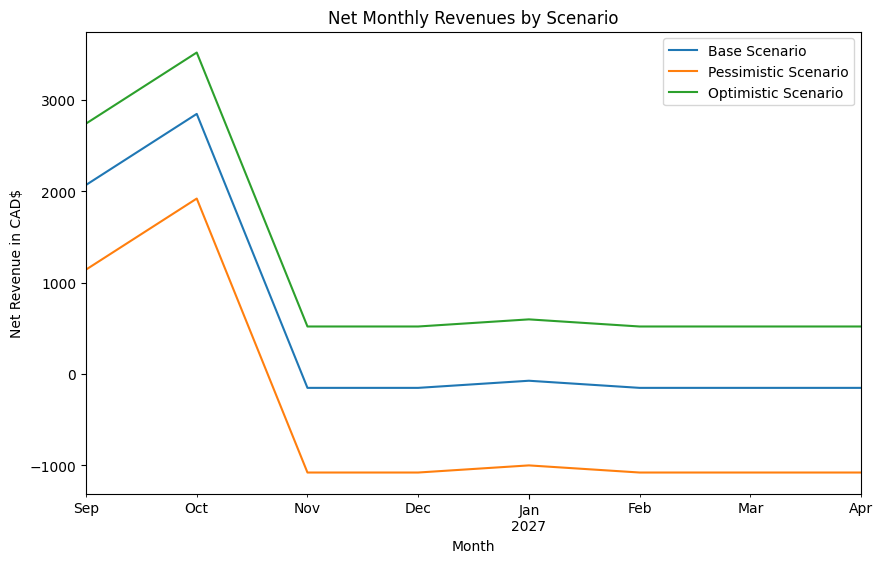

In [139]:
fig, ax = plt.subplots(figsize=(10, 6)) 

net_df['Net'].plot(ax=ax, label='Base Scenario')
net_pess_df['Net'].plot(ax=ax, label='Pessimistic Scenario')
net_opt_df['Net'].plot(ax=ax, label='Optimistic Scenario')

ax.set_title('Net Monthly Revenues by Scenario')
ax.set_xlabel('Month')
ax.set_ylabel('Net Revenue in CAD$')
ax.legend()

plt.show()

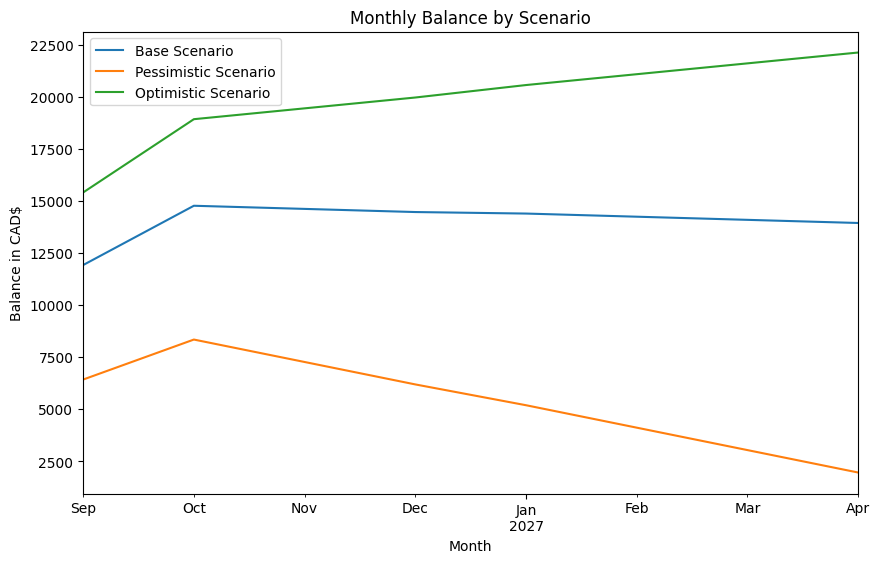

In [140]:
fig, ax = plt.subplots(figsize=(10, 6)) 

net_df['Running Balance'].plot(ax=ax, label='Base Scenario')
net_pess_df['Running Balance'].plot(ax=ax, label='Pessimistic Scenario')
net_opt_df['Running Balance'].plot(ax=ax, label='Optimistic Scenario')

ax.set_title('Monthly Balance by Scenario')
ax.set_xlabel('Month')
ax.set_ylabel('Balance in CAD$')
ax.legend()

plt.show()

Under all scenarios, my finances seem to be viable. I retain a final balance across them all, and am never in the red.

## Sensitivity Analysis

Seeing how outcomes vary with changes in summer work and part-time work revenue.

In [141]:
summer_range = range(0, 13000, 500)   # total summer earnings
work_range = range(0, 1056, 100)      # monthly work income

results = []

for summer in summer_range:
    for work in work_range:
        rev = pess_rev.copy()
         
        rev['Work'] = work 
        
        net = build_net(rev, pess_costs, summer)
        min_balance = int(net['Running Balance'].min())
        
        results.append({
            'summer': summer,
            'work': work,
            'min_balance': min_balance,
            'final_balance': net['Running Balance'].iloc[-1],
            'months_negative': (net['Running Balance'] < 0).sum(),
            'max_deficit': net['Net'].min(),
        })

sens_df = pd.DataFrame(results)
sens_df

,summer,work,min_balance,final_balance,months_negative,max_deficit
0,0,0,-6140,-6140.0,5,-1430.0
1,0,100,-5340,-5340.0,5,-1330.0
2,0,200,-4540,-4540.0,4,-1230.0
3,0,300,-3740,-3740.0,4,-1130.0
4,0,400,-2940,-2940.0,3,-1030.0
...,...,...,...,...,...,...
281,12500,600,11160,11160.0,0,-830.0
282,12500,700,11960,11960.0,0,-730.0
283,12500,800,12760,12760.0,0,-630.0
284,12500,900,13560,13560.0,0,-530.0


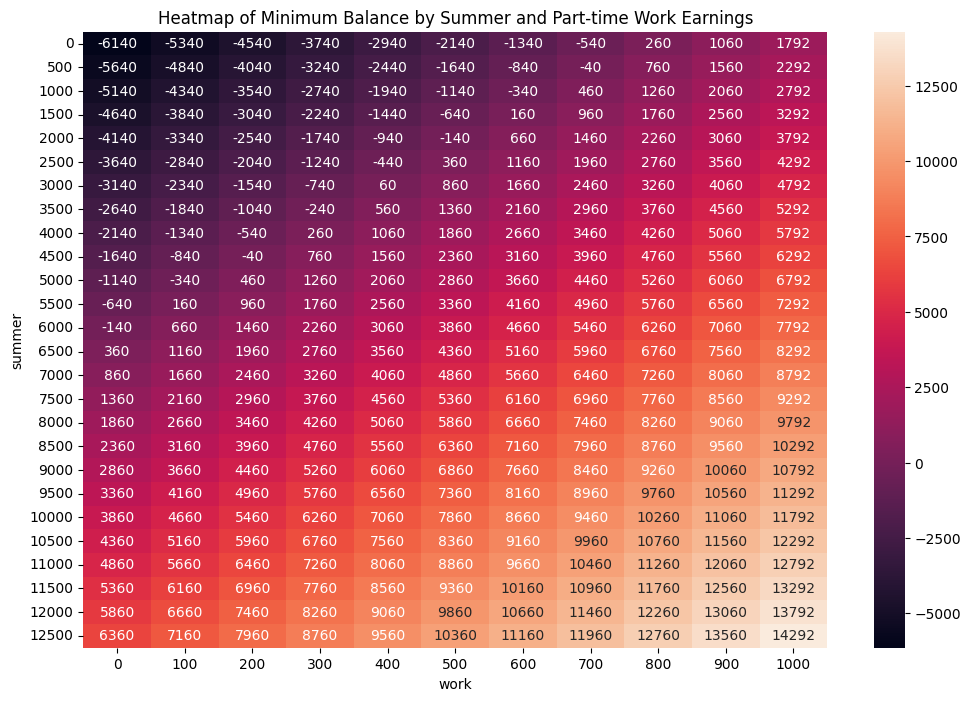

In [142]:
sens_pt = sens_df.pivot_table(values='min_balance', index='summer', columns='work').astype('int64')
plt.figure(figsize=(12, 8))
sns.heatmap(sens_pt, annot=True, fmt='d')
plt.title('Heatmap of Minimum Balance by Summer and Part-time Work Earnings')
plt.show()

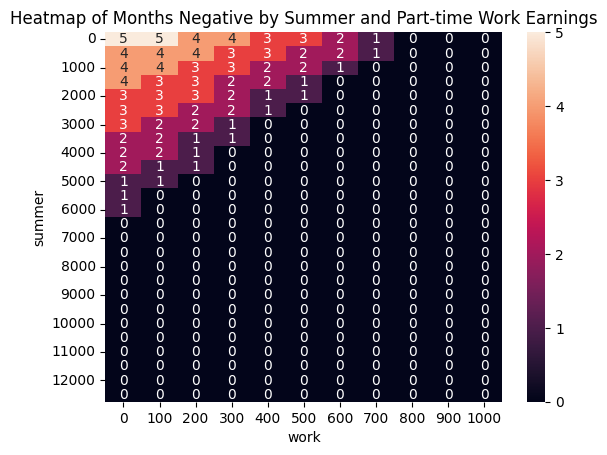

In [143]:
sns.heatmap(sens_df.pivot_table(values='months_negative', index='summer', columns='work'), annot=True)
plt.title('Heatmap of Months Negative by Summer and Part-time Work Earnings')
plt.show()

In [146]:
# Feasible points (never go negative)
feasible = sens_df[sens_df['months_negative'] == 0]

# For each work level, find minimum summer required
frontier = feasible.groupby('work')['summer'].min().reset_index()

frontier

,work,summer
0,0,6500
1,100,5500
2,200,5000
3,300,4000
4,400,3000
5,500,2500
6,600,1500
7,700,1000
8,800,0
9,900,0


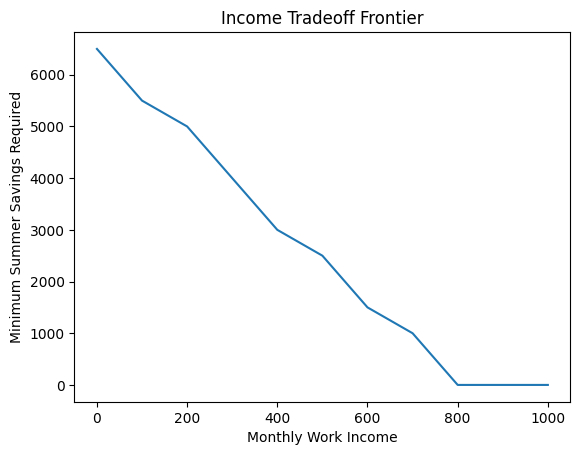

In [147]:
plt.plot(frontier['work'], frontier['summer'])
plt.xlabel('Monthly Work Income')
plt.ylabel('Minimum Summer Savings Required')
plt.title('Income Tradeoff Frontier')
plt.show()

Given my pessimistic cost and revenue scenarios (planning for the worst): in order to avoid any months in the red, I need to have either 6500 in savings to start, or earn 800 every month of the school year. In the middle, I'd need 4000 to start and 300/month from work, or 3000 to start and 400/month from work.

## Residence Cost Comparison

An addendum: I compare costs by residence for a fuller view of comparisons between residences.

In [144]:
residence_costs = {'Woodsworth': [7497, 5118], 'Chestnut': [7804+3862, 5203+3062], 'Knox': [9245, 6651], 'New College': [14965/2, 14965/2], 'Oak': [12167, 12167], 'Trinity': [11284, 11284], 'University College': [8274, 8274]}
res_results = []

for residence in residence_costs:
    costs = pess_costs.copy()

    costs.loc['2026-09-01', 'Residence'] = residence_costs[residence][0] # First residence payment
    costs.loc['2027-01-01', 'Residence'] = residence_costs[residence][1] # Second residence payment
    
    if residence != 'Woodsworth':
        costs['Food'] = 100 # not 0, because of misc food costs like beverages, snacks, and so on.     
    
    res_net = build_net(pess_rev, costs, pess_starting_balance)
    min_balance = int(res_net['Running Balance'].min())
    
    res_results.append({
        'residence': residence,
        'min_balance': min_balance,
        'final_balance': res_net['Running Balance'].iloc[-1],
        'months_negative': (res_net['Running Balance'] < 0).sum(),
        'max_deficit': res_net['Net'].min(),
    })
residence_comp = pd.DataFrame(res_results)
residence_comp.sort_values('min_balance', ascending=False)

,residence,min_balance,final_balance,months_negative,max_deficit
3,New College,2406,2406.0,0,-3014.5
0,Woodsworth,1956,1956.0,0,-1078.0
2,Knox,1475,1475.0,0,-2183.0
6,University College,823,823.0,0,-3806.0
1,Chestnut,-2559,-2560.0,4,-3797.0
5,Trinity,-5196,-5197.0,4,-6816.0
4,Oak,-6962,-6963.0,4,-7699.0


We can see that, among the residence options available to me, New College is most economical; after that, Woodsworth, Knox, and UC The difference between these options is 1583 in remaining balance at the end of the year, but I will still have a decent amount (823, at a minimum) left over. The first three options especially are nigh interchangable depending on how I value their other offerings. Since, personally, I don't value left-over money that much over a better residence life, it makes sense to rank these four options based primarily on other factors, with limited weighting (though non-zero) for left-over cash. The rest of the options are unviable, as they put me in the red, of course.

## Weighted Comparison

A weighted comparison using other categories too. Categories and my weightings:

1. Cost - 0.05 (low-weighted because of marginal differences between the specific residences picked)
2. Room Quality & Amenities - 0.5
3. Community - 0.2
4. Food - 0.2 (prefer kitchen)
5. Location - 0.05

In [145]:
residence_rankings = {'Woodsworth': [2, 1, 3, 1, 3], 'Knox': [3, 4, 4, 3, 4], 'UC': [4, 3, 1, 4, 1], 'New College': [1, 2, 2, 2, 2]} # in order specified above
weightings = [0.05, 0.5, 0.2, 0.2, 0.05]
weighted_rankings = {}

for residence in residence_rankings:
    ranking = sum([a * b for a, b in zip(residence_rankings[residence], weightings)])
    weighted_rankings[residence] = ranking

res_ranks = pd.DataFrame.from_dict(weighted_rankings, orient='index', columns=['Weighted Ranking'])
res_ranks.sort_values('Weighted Ranking')

,Weighted Ranking
Woodsworth,1.55
New College,1.95
UC,2.75
Knox,3.75


We see that according to my weighted preferences across categories and the rankings of these residences on those categories, that Woodsworth is my top choice, followed by NC, UC, and Knox. Rankings were ordinal, not cardinal, so the gap between residences is not properly expressed, but it functions decently generally.